# 02. 전처리

01에서 확인한 데이터셋을 모델링에 쓸 수 있는 형태로 정리한다.

1. train/eval 청크가 겹치지 않는지(leakage) 검증
2. 노이즈 변형 때문에 8배로 늘어난 코퍼스(content)를 청크 단위로 중복 제거
3. 질문 텍스트 공백 정규화

산출물: `document_고무서/output/embedding-finetune/02_preprocessing/`
(이 폴더의 `processed/train_pairs.csv`, `processed/eval_pairs.csv`, `processed/corpus.csv`를
03, 04 노트북이 그대로 읽는다.)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

DATASET_DIR = Path("../dataset")
OUTPUT_DIR = Path("../output/embedding-finetune/02_preprocessing")
PROCESSED_DIR = OUTPUT_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATASET_DIR / "train_pairs.csv")
eval_df = pd.read_csv(DATASET_DIR / "eval_pairs.csv")
print(f"train: {len(train_df)}행 / eval: {len(eval_df)}행")

train: 816행 / eval: 208행


## 1. Train/Eval 청크 중복(leakage) 검증

In [2]:
train_ids = set(train_df["id"])
eval_ids = set(eval_df["id"])
overlap = train_ids & eval_ids

leakage_check = {
    "train_chunks": len(train_ids),
    "eval_chunks": len(eval_ids),
    "overlap_chunks": len(overlap),
    "leakage_free": len(overlap) == 0,
}
with open(OUTPUT_DIR / "leakage_check.json", "w", encoding="utf-8") as f:
    json.dump(leakage_check, f, ensure_ascii=False, indent=2)

assert len(overlap) == 0, f"train/eval 청크가 겹칩니다: {overlap}"
leakage_check

{'train_chunks': 102,
 'eval_chunks': 26,
 'overlap_chunks': 0,
 'leakage_free': True}

## 2. 코퍼스 중복 제거

In [3]:
raw_corpus_rows = len(train_df) + len(eval_df)
corpus_df = (
    pd.concat([train_df, eval_df])[["id", "source_type", "source_id", "content"]]
    .drop_duplicates(subset="id")
    .sort_values("id")
    .reset_index(drop=True)
)
corpus_df.to_csv(PROCESSED_DIR / "corpus.csv", index=False)

dedup_summary = pd.DataFrame(
    [
        {"항목": "중복 제거 전(train+eval 전체 행)", "값": raw_corpus_rows},
        {"항목": "중복 제거 후(고유 청크)", "값": len(corpus_df)},
    ]
)
dedup_summary.to_csv(OUTPUT_DIR / "dedup_summary.csv", index=False)
dedup_summary

,항목,값
0,중복 제거 전(train+eval 전체 행),1024
1,중복 제거 후(고유 청크),128


**왜 중복 제거가 필요한가**: 노트북 01에서 청크당 노이즈 변형 8개를 만들었기 때문에
`train_df`/`eval_df`를 그대로 이어붙이면 같은 문서(content)가 8번씩 코퍼스에 들어간다.
검색 평가용 코퍼스에 정답 문서가 중복으로 여러 번 있으면 실제보다 검색이 쉬워 보이는
착시가 생기므로, 임베딩 대상 코퍼스는 청크 단위로 1개씩만 남긴다.

## 3. 질문 텍스트 정규화

In [4]:
def normalize_whitespace(text: str) -> str:
    return " ".join(str(text).split())


before_example = train_df.iloc[0]["noisy_query"]

for df in (train_df, eval_df):
    df["clean_query"] = df["clean_query"].apply(normalize_whitespace)
    df["noisy_query"] = df["noisy_query"].apply(normalize_whitespace)

after_example = train_df.iloc[0]["noisy_query"]

normalize_example = pd.DataFrame(
    [{"단계": "정규화 전", "noisy_query": before_example}, {"단계": "정규화 후", "noisy_query": after_example}]
)

train_df.to_csv(PROCESSED_DIR / "train_pairs.csv", index=False)
eval_df.to_csv(PROCESSED_DIR / "eval_pairs.csv", index=False)

normalize_example

,단계,noisy_query
0,정규화 전,역할별 마이페이지 셸을 제공한다 업무는 어떤 내용이야? 급한데 빨리 부탁해
1,정규화 후,역할별 마이페이지 셸을 제공한다 업무는 어떤 내용이야? 급한데 빨리 부탁해


## 4. source_type별 코퍼스 커버리지

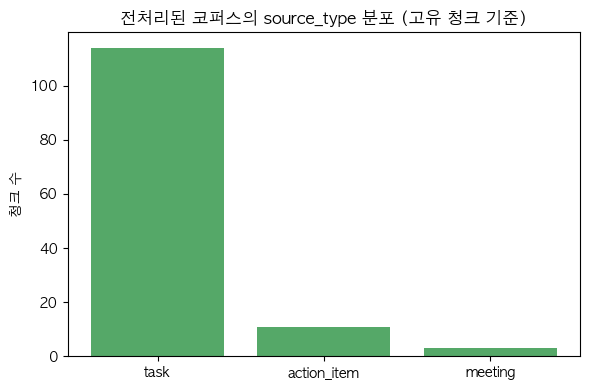

,source_type,count
0,task,114
1,action_item,11
2,meeting,3


In [5]:
coverage = corpus_df["source_type"].value_counts().rename_axis("source_type").reset_index(name="count")
coverage.to_csv(OUTPUT_DIR / "corpus_coverage.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(coverage["source_type"], coverage["count"], color="#55A868")
ax.set_title("전처리된 코퍼스의 source_type 분포 (고유 청크 기준)")
ax.set_ylabel("청크 수")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "corpus_coverage.png", dpi=150)
plt.show()

coverage

## 전처리 결과

- leakage 검증 통과(`leakage_check.json`), 코퍼스 128건으로 중복 제거 완료(`processed/corpus.csv`).
- 정규화된 `processed/train_pairs.csv`, `processed/eval_pairs.csv`를 다음 단계(`03_modeling.ipynb`)에서 사용한다.